In [ ]:
# Ensure the notebook uses the repository root as its working directory whether launched from notebooks/ or the repository root
import os, sys
from pathlib import Path
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


# Data Utilities

In [2]:
import csv
import matplotlib.pyplot as plt
import numpy as np  
import os
from math import log10

ckt_name = "NMCNR"
database_path = "./circuit_database"
csv_path = database_path + "/" + ckt_name + "/result.csv"

## CSV Reader

In [74]:
# Read database_path/ckt_name/result.csv and plot its data as a 3D scatter plot
data = []
with open(csv_path, newline='', encoding='utf-8') as csvfile:
    csvreader = csv.reader(csvfile)
    # Read the header
    header = next(csvreader)
    # Exclude STALE data
    for row in csvreader:
        if row[7] == "STALE":
            continue
        data.append([float(row[0]), float(row[1]), float(row[2]), row[4], row[5]])  # The last two elements are time and performance weight, respectively

## Data Check

In [75]:
# Check whether any non-optimal data are read
all_inferior = []

for i in range(len(data)):
    for j in range(len(data)):
        if data[i][0] < data[j][0] and data[i][1] < data[j][1] and data[i][2] > data[j][2]:
            all_inferior.append(data[i])
            print(f"inferior data: GBW={data[i][0]}, Gain={data[i][1]}, Pdiss={data[i][2]}")

if all_inferior:
    print(f"Warning: There are inferior data in the database of {ckt_name}!")
    
else:
    print(f"All data in the database of {ckt_name} are optimal!")

All data in the database of NMCNR are optimal!


## Scatter Plot (considering different performance weights)

In [76]:
# # Plot the scatter for weight 1 1 1
# data_111_weight = []
# for i in range(len(data)):
#     if str(data[i][4]) == "[1, -1, 0]":
#         data_111_weight.append(data[i])
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.set_title("Performance of SMC")
# ax.set_xlabel("GBW")
# ax.set_ylabel("Gain")
# ax.set_zlabel("Pdiss")
# ax.scatter([20*log10(d[0]) for d in data_111_weight], [d[1] for d in data_111_weight], [0.1-d[2] for d in data_111_weight], c='r', marker='o')
# plt.show()

No data with performance weight [1, 0, 0] in the database of NMCNR!
No data with performance weight [0, 1, 0] in the database of NMCNR!
No data with performance weight [0, 0, 1] in the database of NMCNR!
No data with performance weight [0, 0, 0] in the database of NMCNR!
No data with performance weight [1, -1, 0] in the database of NMCNR!
No data with performance weight [1, -1, 1] in the database of NMCNR!
No data with performance weight [-1, 1, 1] in the database of NMCNR!
No data with performance weight [-1, -1, -1] in the database of NMCNR!
No data with performance weight MOO-TuRBO1 in the database of NMCNR!
No data with performance weight MOO-TuRBOm in the database of NMCNR!


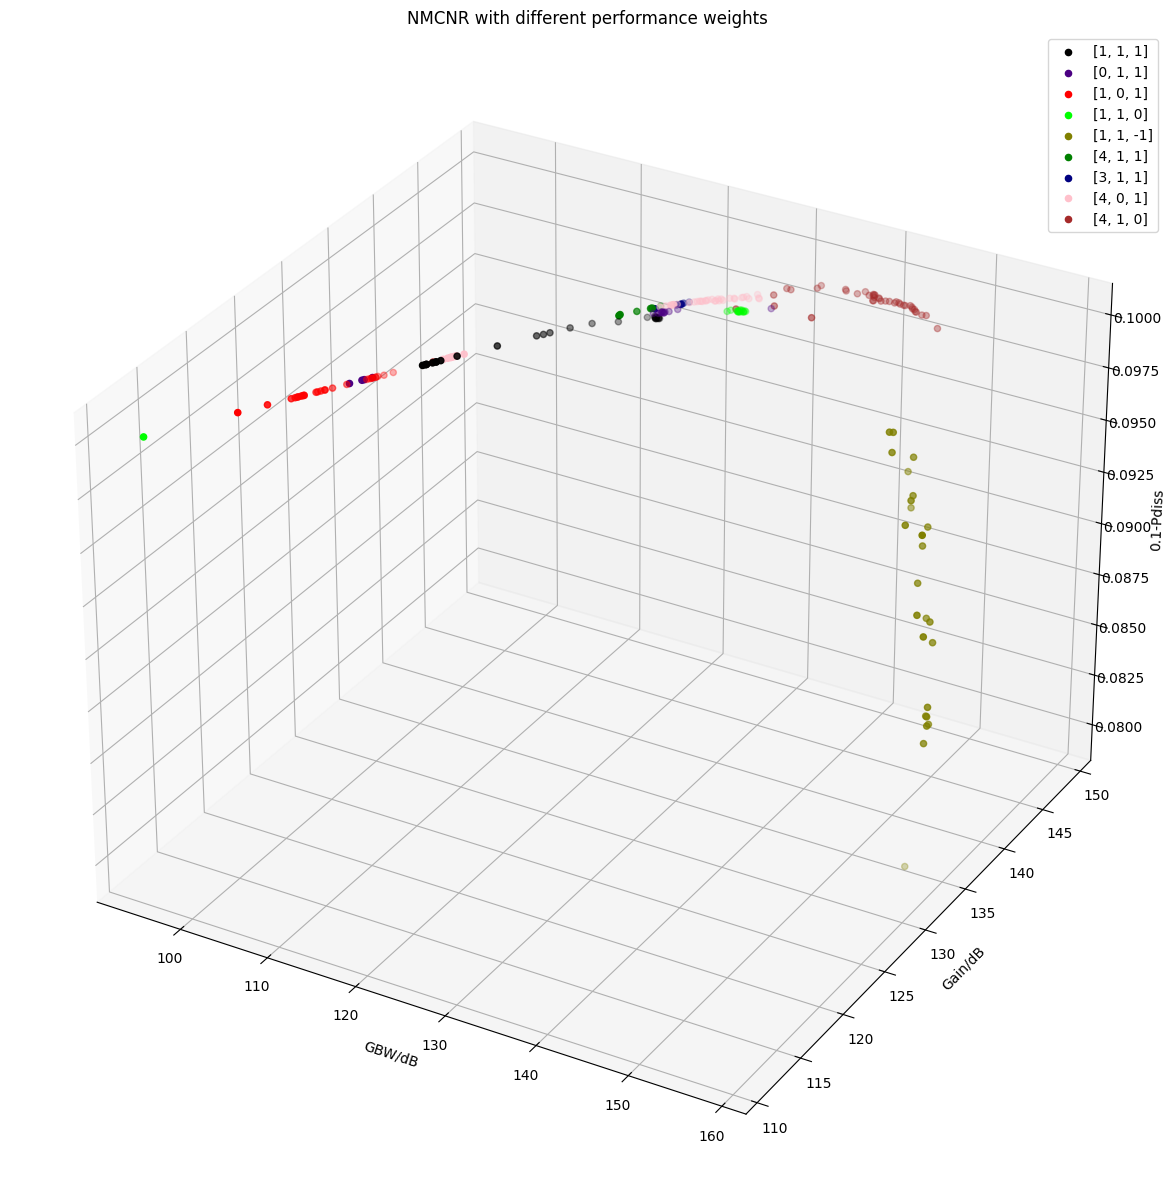

In [77]:
performance_weights = [
    [1, 1, 1],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0],
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [0, 0, 0],
    [1, -1, 0],  # Maximize GBW; `Gain` and `Pdiss` are not important
    [1, 1, -1],
    [1, -1, 1],
    [-1, 1, 1],
    [-1, -1, -1],
    [4, 1, 1],  # The fitness function uses A = GBW_VOUT
    [3, 1, 1],  # The fitness function uses A = sqrt(GBW_VOUT)
    [4, 0, 1],  # The fitness function uses A = GBW_VOUT
    [4, 1, 0],  # The fitness function uses A = GBW_VOUT
    "MOO-TuRBO1",
    "MOO-TuRBOm"
    ]

data_with_diff_weights = []

for j in range(len(performance_weights)):
    data_with_weight = []
    
    for i in range(len(data)):
        if str(data[i][4]) == str(performance_weights[j]):
            data_with_weight.append([data[i][0], data[i][1], data[i][2]])
   
    data_with_diff_weights.append(data_with_weight)

# High-contrast color matrix for c=, with 20 colors
colors = [
    "#000000",  # Black
    "#4B0082",  # Indigo
    "#FF0000",  # Red
    "#00FF00",  # Lime
    "#0000FF",  # Blue
    "#FFFF00",  # Yellow
    "#00FFFF",  # Cyan
    "#FF00FF",  # Magenta
    "#800000",  # Maroon
    "#808000",  # Olive
    "#008080",  # Teal
    "#800080",  # Purple
    "#FFA500",  # Orange
    "#008000",  # Green
    "#000080",  # Navy
    "#FFC0CB",  # Pink
    "#A52A2A",  # Brown
    "#A9A9A9",  # DarkGray
    "#ADD8E6",  # LightBlue
    "#FFFFE0"   # LightYellow
]

# Plot by weight; skip weights with no data
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

for i in range(len(data_with_diff_weights)):
    if data_with_diff_weights[i]:
        data_with_diff_weights[i] = np.array(data_with_diff_weights[i])
        
        # # GBW, Gain/dB, 0.1-Pdiss
        # ax.scatter(data_with_diff_weights[i][:, 0], data_with_diff_weights[i][:, 1], 0.1-data_with_diff_weights[i][:, 2], c=colors[i%10], label=f"{performance_weights[i]}")
        
        # GBW/dB, Gain/dB, 0.1-Pdiss
        ax.scatter(20*np.log10(data_with_diff_weights[i][:, 0]), data_with_diff_weights[i][:, 1], 0.1-data_with_diff_weights[i][:, 2], c=colors[i%20], label=f"{performance_weights[i]}")
        
    else:
        print(f"No data with performance weight {performance_weights[i]} in the database of {ckt_name}!")

ax.set_xlabel('GBW/dB')
ax.set_ylabel('Gain/dB')
ax.set_zlabel('0.1-Pdiss')
ax.set_title(f"{ckt_name} with different performance weights")
ax.legend()

plt.show()


In [78]:
# # Plot with coordinate 0 as GBW/Gain (after unit conversion), 1 as `Gain`, and 2 as `Pdiss` instead of GBW
# fig = plt.figure(figsize=(20, 20))
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(data[:, 0] / (10 ** (data[:, 1] / 20)), data[:, 1], data[:, 2], c='r', marker='o')
# ax.set_xlabel('GBW/Gain')
# ax.set_ylabel('Gain')
# ax.set_zlabel('Pdiss')

# # Set axis limits
# ax.set_xlim(0, 1000)

# plt.show()

## Scale Plot for All Circuits

Reading ./circuit_database/SMC/result.csv...
Reading ./circuit_database/DFCFC1/result.csv...
Reading ./circuit_database/AZC/result.csv...
Reading ./circuit_database/NGCC/result.csv...
Reading ./circuit_database/NMCNR/result.csv...
Reading ./circuit_database/IAC/result.csv...
Reading ./circuit_database/TCFC/result.csv...


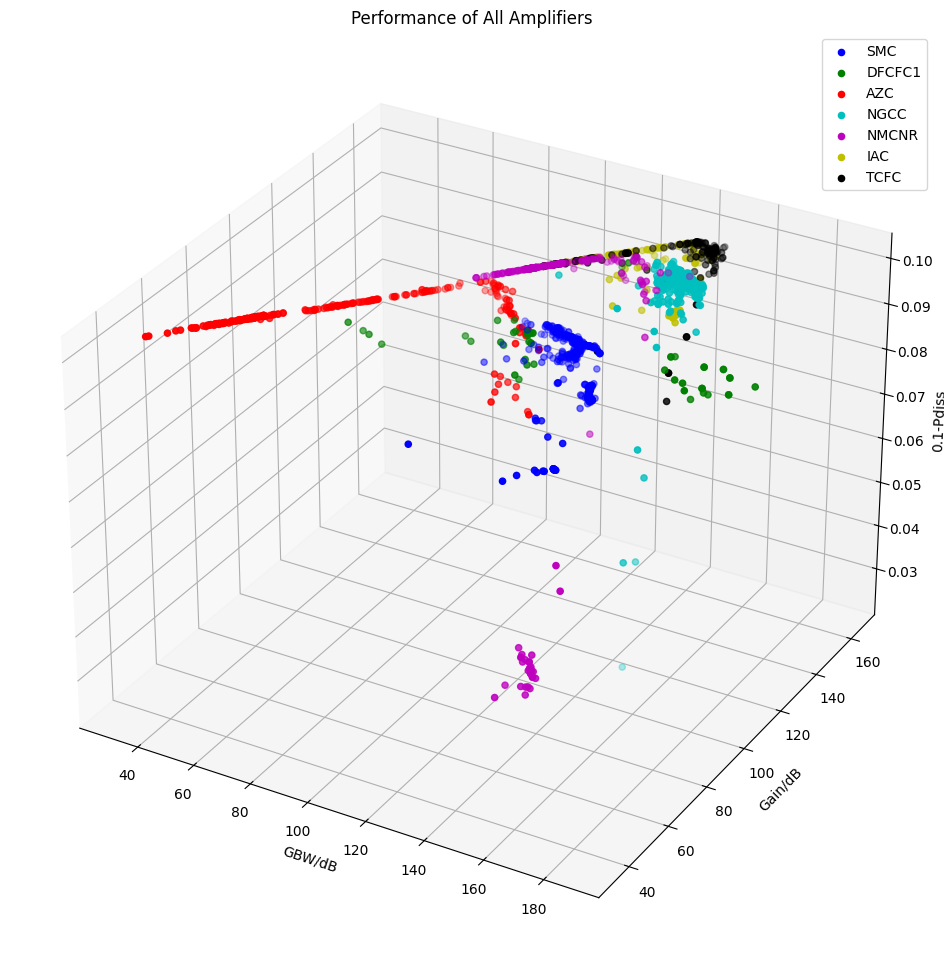

In [5]:
data_all = []

# Read result.csv from every ckt_name directory under database_path and plot the data as a 3D scatter plot
# Get the names of all directories under database_path
ckt_names = []
for entry in os.listdir(database_path):
    if os.path.isdir(os.path.join(database_path, entry)):
        ckt_names.append(entry)

for ckt_name in ckt_names:
    csv_path = database_path + "/" + ckt_name + "/result.csv"
    data_ = []
    print(f"Reading {csv_path}...")
    with open(csv_path, newline='', encoding='utf-8') as csvfile:
        csvreader = csv.reader(csvfile)
        # Read the header
        header = next(csvreader)
        # Exclude STALE data
        for row in csvreader:
            # if row[7] == "STALE":
            #     continue
            data_.append([float(row[0]), float(row[1]), float(row[2])])
    data_all.append(data_)

# High-contrast color matrix for c=, with 10 colors
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple']

# Plot data_all, using a different scatter color for each ckt_name and showing ckt_name in the legend
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')
for i in range(len(data_all)):
    data = np.array(data_all[i])
    # Use GBW/Gain, `Gain`, and 0.1-Pdiss as the axes
    # ax.scatter(data[:, 0]/(10**(data[:, 1]/20)), data[:, 1], 0.1-data[:, 2], marker='o', label=ckt_names[i], c=colors[i%10])
    
    # Use GBW (dB), `Gain`, and 0.1-Pdiss as the axes
    ax.scatter(20*np.log10(data[:, 0]), data[:, 1], 0.1-data[:, 2], marker='o', label=ckt_names[i], c=colors[i%10])
    
    # Use GBW, `Gain`, and 0.1-Pdiss as the axes
    # ax.scatter(data[:, 0], data[:, 1], 0.1-data[:, 2], marker='o', label=ckt_names[i], c=colors[i%10])
    
# Axes 
ax.set_xlabel('GBW/dB')
ax.set_ylabel('Gain/dB')
ax.set_zlabel('0.1-Pdiss')

# Plot title
ax.set_title("Performance of All Amplifiers")

# Legend
plt.legend()

# # Set axis limits
# ax.set_xlim(1e6, 5e7)
# ax.set_zlim(0, 0.005)

plt.show()

## Gather all data from different circuits to a single csv file with out stale data

In [4]:
import time

data_all_full = []

# Read result.csv from every ckt_name directory under database_path and plot the data as a 3D scatter plot
# Get the names of all directories under database_path
ckt_names = []
header = []
# Directories only
for entry in os.listdir(database_path):
    if os.path.isdir(os.path.join(database_path, entry)):
        ckt_names.append(entry)

for ckt_name in ckt_names:
    csv_path = database_path + "/" + ckt_name + "/result.csv"
    
    with open(csv_path, newline='', encoding='utf-8') as csvfile:
        csvreader = csv.reader(csvfile)
        # Read the header and store it in header
        if not header:
            header = next(csvreader)
        else:
            next(csvreader)
        # Exclude STALE data
        for row in csvreader:
            if row[7] == "STALE":
                continue
            row.insert(0, ckt_name)
            data_all_full.append(row)

# Print header
header.insert(0, "circuit name")
print(header)

# Print the first five rows of data_all_full
for i in range(5):
    print(data_all_full[i])    
            
# Save to a CSV file
csv_all_full_path = database_path + "/result_all.csv"

with open(csv_all_full_path, 'w', newline='', encoding='utf-8') as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(header)
    for _data in data_all_full:
        csvwriter.writerow(_data)
    
# Save an additional copy    
timestamp = time.strftime("%Y%m%d-%H%M%S")
csv_all_full_path = csv_all_full_path.replace(".csv", f"_{timestamp}.csv")
os.system(f"cp {database_path}/result_all.csv {csv_all_full_path}")
print(f"All data saved to {csv_all_full_path}!")

['circuit name', 'GBW', ' Gain', ' Pdiss', ' Fitness', ' time', ' performance weight', ' solution vector', ' solution path']
['SMC', '29067700.0', '96.6741', '0.00139515', '-10.318789765876001', '2025-0521-122240', '[1, 1, 1]', '[3.80919891e-04 1.72731099e-06 4.99200726e-05 1.99988463e-06\n 1.26033647e-05 9.67664329e-07 7.88307474e-04 5.23325939e-07\n 6.42057476e-06 7.00430557e-07 1.65062625e-12]', './circuit_database/SMC/result_folder/2025-0521-122240']
['SMC', '15400900.0', '92.7901', '0.000899637', '-10.233478792277431', '2025-0521-122240', '[1, 1, 1]', '[2.77272546e-04 1.99316626e-06 1.88045926e-05 1.66961868e-06\n 1.11902035e-05 1.56060241e-06 7.64834322e-04 5.44653120e-07\n 1.18859450e-06 5.26599602e-07 1.76551257e-12]', './circuit_database/SMC/result_folder/2025-0521-122240']
['SMC', '25186900.0', '97.4497', '0.00126597', '-10.298751303664504', '2025-0521-122240', '[1, 1, 1]', '[3.90834691e-04 1.99001668e-06 8.15483540e-05 1.96647864e-06\n 1.12600671e-05 1.04004627e-06 9.1289482